In [ ]:
# !pip install pytorch_forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 200)

In [ ]:
train = pd.read_csv('train.csv')
train = train.drop('date.1', axis=1)
valid = pd.read_csv('valid.csv')
valid = valid.drop('date.1', axis=1)

In [ ]:
train_df = train.copy()
val_df = valid.copy()

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11464 entries, 0 to 11463
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  11464 non-null  object 
 1   open                  11464 non-null  float64
 2   high                  11464 non-null  float64
 3   low                   11464 non-null  float64
 4   close                 11464 non-null  float64
 5   volume                11464 non-null  float64
 6   asset                 11464 non-null  object 
 7   target                11464 non-null  float64
 8   MACD                  11464 non-null  float64
 9   BB_Width              11464 non-null  float64
 10  ATR_14                11464 non-null  float64
 11  vader_score           11464 non-null  float64
 12  roberta_score         11464 non-null  float64
 13  sentiment_missing     11464 non-null  int64  
 14  EMA_reversion_signal  11464 non-null  float64
 15  high_atr           

In [ ]:
train['date'] = pd.to_datetime(train['date'])
valid['date'] = pd.to_datetime(valid['date'])

In [ ]:
train.head()

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,ATR_14,vader_score,roberta_score,sentiment_missing,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,BTC,31613.56,-113.205712,0.018995,243.419286,0.176910,0.100000,0,143.515362,False,2.397895,False,0,2021,7,17,5,5
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,BTC,31545.10,-99.528202,0.018335,223.873571,0.037589,0.000000,0,109.357975,False,2.944439,False,0,2021,7,17,6,5
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,BTC,31730.45,-93.139176,0.016328,219.865714,0.295887,0.133333,0,94.474802,False,2.772589,False,0,2021,7,17,7,5
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,BTC,31641.49,-72.286359,0.016332,251.252143,0.197756,0.074074,0,52.692530,False,3.332205,False,0,2021,7,17,8,5
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,BTC,31323.53,-62.221430,0.016317,249.166429,0.235200,-0.008753,0,37.159787,False,6.126869,False,0,2021,7,17,9,5


In [ ]:
valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2866 entries, 0 to 2865
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  2866 non-null   datetime64[ns]
 1   open                  2866 non-null   float64       
 2   high                  2866 non-null   float64       
 3   low                   2866 non-null   float64       
 4   close                 2866 non-null   float64       
 5   volume                2866 non-null   float64       
 6   asset                 2866 non-null   object        
 7   target                2866 non-null   float64       
 8   MACD                  2866 non-null   float64       
 9   BB_Width              2866 non-null   float64       
 10  ATR_14                2866 non-null   float64       
 11  vader_score           2866 non-null   float64       
 12  roberta_score         2866 non-null   float64       
 13  sentiment_missing 

In [ ]:
train[[
    'open',
    'high',
    'low',
    'close',
    'volume',
    'target',
    'MACD',
    'BB_Width',
    'ATR_14',
    'vader_score',
    'roberta_score',
    'EMA_reversion_signal',
    'high_atr',
    'log_tweet_count',
    'tweet_spike',
    'MACD_extreme_flag'
]].describe()

,open,high,low,close,volume,target,MACD,BB_Width,ATR_14,vader_score,roberta_score,EMA_reversion_signal,log_tweet_count,MACD_extreme_flag
count,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000,11464.000000
mean,37323.310904,37494.912667,37146.276779,37322.419035,1642.823036,37321.524421,-6.432859,0.021389,348.745188,0.043177,0.001109,6.388178,1.591427,0.239881
std,13401.839423,13459.300920,13339.774634,13402.647202,1872.470211,13403.378108,311.180459,0.015256,183.194869,0.081605,0.039408,363.684563,2.813176,0.427030
min,17785.630000,18082.970000,17600.750000,17785.630000,116.260000,17785.630000,-2348.658989,0.001627,25.382143,-0.094748,-0.293860,-1698.489396,0.000000,0.000000
25%,22669.417500,22794.115000,22548.120000,22661.925000,711.177500,22660.955000,-146.563173,0.011189,202.945179,0.000000,0.000000,-159.846851,0.000000,0.000000
50%,39405.680000,39572.960000,39184.190000,39405.680000,1175.275000,39405.680000,-5.396256,0.017147,330.693929,0.000000,0.000000,6.079907,0.000000,0.000000
75%,46889.762500,47100.990000,46674.252500,46892.940000,1954.812500,46892.940000,147.336958,0.026632,453.583571,0.000000,0.000000,164.844412,0.000000,0.000000
max,68624.180000,68978.640000,68464.620000,68624.180000,80010.580000,68624.180000,1272.364104,0.123547,1431.325714,0.562269,0.757642,2944.765409,8.209580,1.000000


In [ ]:
# Convert bool to int (False=0, True=1)
train['high_atr'] = train['high_atr'].astype(int)
train['tweet_spike'] = train['tweet_spike'].astype(int)

valid['high_atr'] = valid['high_atr'].astype(int)
valid['tweet_spike'] = valid['tweet_spike'].astype(int)

In [ ]:
train["return"] = train["target"] - train["close"]
valid["return"] = valid["target"] - valid["close"]

In [ ]:
train.head()

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,ATR_14,vader_score,roberta_score,sentiment_missing,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week,return
0,2021-07-17 05:00:00,31410.68,31556.38,31406.10,31500.51,1108.13,BTC,31613.56,-113.205712,0.018995,243.419286,0.176910,0.100000,0,143.515362,0,2.397895,0,0,2021,7,17,5,5,113.05
1,2021-07-17 06:00:00,31500.51,31614.95,31475.15,31613.56,813.76,BTC,31545.10,-99.528202,0.018335,223.873571,0.037589,0.000000,0,109.357975,0,2.944439,0,0,2021,7,17,6,5,-68.46
2,2021-07-17 07:00:00,31613.56,31615.69,31495.93,31545.10,940.96,BTC,31730.45,-93.139176,0.016328,219.865714,0.295887,0.133333,0,94.474802,0,2.772589,0,0,2021,7,17,7,5,185.35
3,2021-07-17 08:00:00,31545.10,31966.25,31383.23,31730.45,1320.14,BTC,31641.49,-72.286359,0.016332,251.252143,0.197756,0.074074,0,52.692530,0,3.332205,0,0,2021,7,17,8,5,-88.96
4,2021-07-17 09:00:00,31730.45,31809.73,31632.94,31641.49,860.88,BTC,31323.53,-62.221430,0.016317,249.166429,0.235200,-0.008753,0,37.159787,0,6.126869,0,0,2021,7,17,9,5,-317.96


# TFT

In [ ]:
continuous_cols = [
    'open','high','low','close','volume',
    'MACD','BB_Width','ATR_14',
    'EMA_reversion_signal'
]

binary_cols = [
    'high_atr','tweet_spike','MACD_extreme_flag'
]

# Optional: log transform volume first
train['volume'] = np.log1p(train['volume'])
valid['volume'] = np.log1p(valid['volume'])

# Fit only on training
scaler_X = StandardScaler()
train[continuous_cols] = scaler_X.fit_transform(train[continuous_cols])
valid[continuous_cols] = scaler_X.transform(valid[continuous_cols])


In [ ]:
train.head()

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,ATR_14,vader_score,roberta_score,sentiment_missing,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week,return
0,2021-07-17 05:00:00,-0.441200,-0.441241,-0.430324,-0.434404,-0.115761,BTC,31613.56,-0.343137,-0.156949,-0.574964,0.176910,0.100000,0,0.377066,0,2.397895,0,0,2021,7,17,5,5,113.05
1,2021-07-17 06:00:00,-0.434497,-0.436889,-0.425148,-0.425969,-0.528441,BTC,31545.10,-0.299181,-0.200178,-0.681662,0.037589,0.000000,0,0.283142,0,2.944439,0,0,2021,7,17,6,5,-68.46
2,2021-07-17 07:00:00,-0.426061,-0.436834,-0.423590,-0.431077,-0.334343,BTC,31730.45,-0.278649,-0.331774,-0.703541,0.295887,0.133333,0,0.242217,0,2.772589,0,0,2021,7,17,7,5,185.35
3,2021-07-17 08:00:00,-0.431169,-0.410787,-0.432039,-0.417247,0.118275,BTC,31641.49,-0.211634,-0.331460,-0.532205,0.197756,0.074074,0,0.127326,0,3.332205,0,0,2021,7,17,8,5,-88.96
4,2021-07-17 09:00:00,-0.417339,-0.422416,-0.413319,-0.423885,-0.453217,BTC,31323.53,-0.179288,-0.332460,-0.543591,0.235200,-0.008753,0,0.084614,0,6.126869,0,0,2021,7,17,9,5,-317.96


In [ ]:
target = 'return'

time_varying_unknown_reals = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "MACD",
    "BB_Width",
    "ATR_14",
    "vader_score",
    "roberta_score",
    "sentiment_missing",
    "EMA_reversion_signal",
    "high_atr",
    "log_tweet_count",
    "tweet_spike",
    "MACD_extreme_flag"
]

time_varying_known_reals = [
    "month",
    "day",
    "year",
    "hour"
]

In [ ]:
train = train.sort_values(["asset", "date"])
train["time_idx"] = train.groupby("asset").cumcount()

valid = valid.sort_values(["asset", "date"])
valid["time_idx"] = valid.groupby("asset").cumcount()

In [ ]:
train

,date,open,high,low,close,volume,asset,target,MACD,BB_Width,ATR_14,vader_score,roberta_score,sentiment_missing,EMA_reversion_signal,high_atr,log_tweet_count,tweet_spike,MACD_extreme_flag,year,month,day,hour,day_of_week,return,time_idx
0,2021-07-17 05:00:00,-0.441200,-0.441241,-0.430324,-0.434404,-0.115761,BTC,31613.56,-0.343137,-0.156949,-0.574964,0.176910,0.100000,0,0.377066,0,2.397895,0,0,2021,7,17,5,5,113.05,0
1,2021-07-17 06:00:00,-0.434497,-0.436889,-0.425148,-0.425969,-0.528441,BTC,31545.10,-0.299181,-0.200178,-0.681662,0.037589,0.000000,0,0.283142,0,2.944439,0,0,2021,7,17,6,5,-68.46,1
2,2021-07-17 07:00:00,-0.426061,-0.436834,-0.423590,-0.431077,-0.334343,BTC,31730.45,-0.278649,-0.331774,-0.703541,0.295887,0.133333,0,0.242217,0,2.772589,0,0,2021,7,17,7,5,185.35,2
3,2021-07-17 08:00:00,-0.431169,-0.410787,-0.432039,-0.417247,0.118275,BTC,31641.49,-0.211634,-0.331460,-0.532205,0.197756,0.074074,0,0.127326,0,3.332205,0,0,2021,7,17,8,5,-88.96,3
4,2021-07-17 09:00:00,-0.417339,-0.422416,-0.413319,-0.423885,-0.453217,BTC,31323.53,-0.179288,-0.332460,-0.543591,0.235200,-0.008753,0,0.084614,0,6.126869,0,0,2021,7,17,9,5,-317.96,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11459,2022-11-06 10:00:00,-1.200184,-1.204814,-1.192659,-1.198052,-1.154234,BTC,21253.49,0.048401,-1.039289,-1.533408,0.000000,0.000000,1,0.006826,0,0.000000,0,0,2022,11,6,10,6,-12.56,11459
11460,2022-11-06 11:00:00,-1.198191,-1.205147,-1.196868,-1.198989,-0.196435,BTC,21228.61,0.049189,-1.041738,-1.509708,0.000000,0.000000,1,-0.002991,0,0.000000,0,0,2022,11,6,11,6,-24.88,11460
11461,2022-11-06 12:00:00,-1.199128,-1.205590,-1.193987,-1.200846,-0.538595,BTC,21217.30,0.043103,-1.048298,-1.511845,0.000000,0.000000,1,0.000868,0,0.000000,0,0,2022,11,6,12,6,-11.31,11461
11462,2022-11-06 13:00:00,-1.200985,-1.207275,-1.194864,-1.201690,-0.386480,BTC,21225.52,0.035180,-1.054487,-1.524132,0.000000,0.000000,1,0.008028,0,0.000000,0,0,2022,11,6,13,6,8.22,11462


In [ ]:
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss


training = TimeSeriesDataSet(
    train,
    time_idx="time_idx",
    target=target,
    group_ids=["asset"],
    max_encoder_length=34,
    max_prediction_length=6,
    static_categoricals=["asset"],
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
)

validation = TimeSeriesDataSet.from_dataset(training, valid)

train_loader = training.to_dataloader(train=True, batch_size=64)
val_loader = validation.to_dataloader(train=False, batch_size=64)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=len([0.1, 0.5, 0.9]),
    loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9])
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    devices=1,
    gradient_clip_val=0.1
)

trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

best_model_path = trainer.checkpoint_callback.best_model_path
best_model = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │     48 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 14.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     51 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 31.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 31.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 502                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
predictions = best_model.predict(
    val_loader,
    return_x=True,
    return_y=True
)


pred_tensor = predictions.output  # (batch, 6, 3)
pred_last = pred_tensor[:, -1]   # last horizon, median

pred_last = pred_last.detach().cpu().numpy()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

In [ ]:
original_df = pd.DataFrame(
    scaler_X.inverse_transform(valid[continuous_cols]),
    columns=continuous_cols,
    index=valid.index
)

original_df = original_df.iloc[-len(pred_last):]

In [ ]:
valid_output = valid.iloc[-len(pred_last):].copy()
valid_output["pred_return"] = pred_last
valid_output["true_return"] = valid_output["return"]

In [ ]:
tch = 0.33684210526315794
threshold = valid_output["pred_return"].std() * tch

valid_output["signal"] = np.where(
    valid_output["pred_return"] > threshold, 1,
    np.where(valid_output["pred_return"] < -threshold, -1, 0)
)

valid_output["strategy_return"] = (
    valid_output["signal"] * valid_output["true_return"]
)

In [ ]:
valid_output[["true_return", "pred_return", "signal", "strategy_return"]].sample(50)

,true_return,pred_return,signal,strategy_return
2127,-8.79,8.681620,1,-8.79
644,16.67,-0.085579,0,0.00
2320,26.76,-32.121460,-1,-26.76
2314,-29.67,-31.516111,-1,29.67
2026,-87.56,24.477209,1,-87.56
643,-16.38,0.340634,0,-0.00
2003,-99.37,-1.311856,0,-0.00
1599,-12.82,23.899279,1,-12.82
1907,56.43,-0.089238,0,0.00
696,-39.20,7.508084,1,-39.20


In [ ]:
wins = valid_output[valid_output["strategy_return"] > 0]
losses = valid_output[valid_output["strategy_return"] < 0]

win_rate = len(wins) / len(valid_output)
loss_rate = len(losses) / len(valid_output)

avg_win = wins["strategy_return"].mean()
avg_loss = losses["strategy_return"].abs().mean()

expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)

print("Win Rate:", win_rate)
print("Loss Rate:", loss_rate)
print("Avg Win:", avg_win)
print("Avg Loss:", avg_loss)
print("Expectancy per trade:", expectancy)

Win Rate: 0.2458436505129112
Loss Rate: 0.2497347010965688
Avg Win: 74.72389928057557
Avg Loss: 68.69233711048162
Expectancy per trade: 1.2155359037849287


In [ ]:
# threshold_grid = np.linspace(0.1, 1.0, 20)  # multiples of std

# results = []

# std_pred = valid_output["pred_return"].std()

# for k in threshold_grid:
#     threshold = std_pred * k

#     signal = np.where(
#         valid_output["pred_return"] > threshold, 1,
#         np.where(valid_output["pred_return"] < -threshold, -1, 0)
#     )

#     strat_ret = signal * valid_output["true_return"]

#     wins = strat_ret[strat_ret > 0]
#     losses = strat_ret[strat_ret < 0]

#     if len(wins) > 0 and len(losses) > 0:
#         win_rate = len(wins) / len(strat_ret)
#         loss_rate = len(losses) / len(strat_ret)
#         avg_win = wins.mean()
#         avg_loss = abs(losses.mean())

#         expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)

#         results.append((k, expectancy, len(strat_ret[strat_ret != 0])))

# results = sorted(results, key=lambda x: x[1], reverse=True)

# print(results[:5])

[(np.float64(0.33684210526315794), np.float64(0.5708949416342399), 1699), (np.float64(0.24210526315789474), np.float64(0.4874142200212255), 1955), (np.float64(0.38421052631578945), np.float64(0.32275910859568313), 1577), (np.float64(0.2894736842105263), np.float64(0.07344888574459674), 1825), (np.float64(0.4789473684210527), np.float64(0.06377078174743289), 1362)]


In [ ]:
# import numpy as np
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_true = valid_output["target"].values
# y_pred = valid_output["prediction"].values

# mae = mean_absolute_error(y_true, y_pred)
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# r2 = r2_score(y_true, y_pred)
# direction_true = np.sign(np.diff(y_true))
# direction_pred = np.sign(np.diff(y_pred))

# directional_accuracy = np.mean(direction_true == direction_pred)

# print("Directional Accuracy:", directional_accuracy)


# print("MAE:", mae)
# print("RMSE:", rmse)
# print("R2:", r2)

Directional Accuracy: 0.45152158527954706
MAE: 56.80185292077396
RMSE: 104.95286084832266
R2: 0.9988281785773806


In [ ]:
# Directional Accuracy: 0.45399858457183295
# MAE: 57.252629154044975
# RMSE: 105.4147079779072
# R2: 0.9988178426390965

# Without sentiments:
# Directional Accuracy: 0.45470629865534323
# MAE: 56.75793177452009
# RMSE: 104.71182361032102
# R2: 0.9988335548625658

# only prices and technical indicators
# Directional Accuracy: 0.45470629865534323
# MAE: 57.36262140185771
# RMSE: 105.47201494507638
# R2: 0.9988165569690257

# only price
# Directional Accuracy: 0.45364472753007784
# MAE: 57.26318322315432
# RMSE: 105.39480036617776
# R2: 0.9988182890987604

SyntaxError: invalid syntax (ipython-input-122568951.py, line 6)

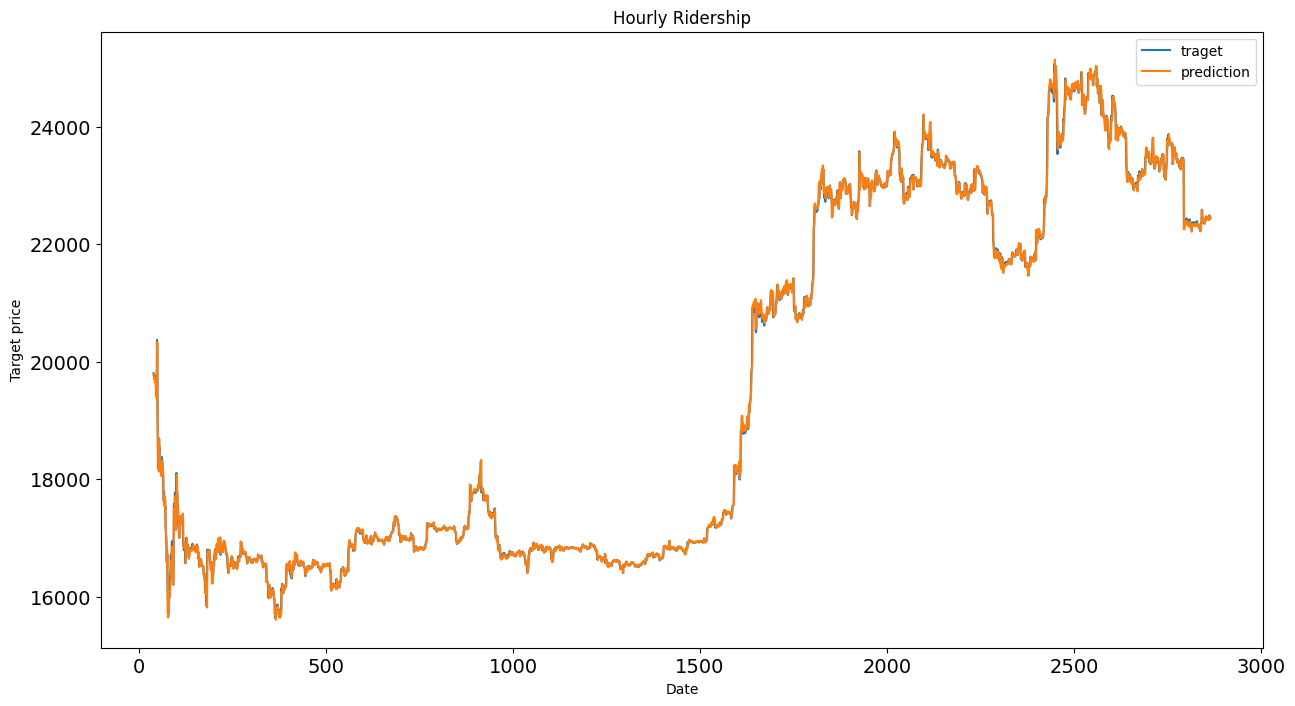

In [ ]:
valid_output.target.plot(figsize=(15, 8), title='Hourly Ridership', fontsize=14, label='traget')
valid_output.prediction.plot(figsize=(15, 8), title='Hourly Ridership', fontsize=14, label='prediction')
plt.xlabel('Date')
plt.ylabel('Target price')
plt.legend(loc='best')
plt.show()